# Label3DMaize coarse segmentation — adapted Python demonstration

Reproduction of the coarse organ-segmentation pipeline of:
**Miao T., Wen W., Li Y., Wu S., Zhu C., Guo X. (2021). *Label3DMaize: toolkit for 3D point cloud data annotation of maize shoots.* GigaScience 10(5): giab031.** https://doi.org/10.1093/gigascience/giab031

- Author source (MATLAB, GPL-3.0): https://github.com/syau-miao/Label3DMaize pinned commit `37a1317ae43fb243a83fa254be797f74e1259c9c`
- Data: `SupplementaryData/S1` of the same repository (also GigaDB https://doi.org/10.5524/100884, CC0)

**ADAPTED PYTHON DEMONSTRATION — AI-assisted translation from MATLAB; the authors did not provide this Colab implementation.** The executed example and listed checks were validated, but untested behavior is not guaranteed.
The original toolkit is an interactive MATLAB GUI (`Label3DMaize`, MATLAB R2017a); this notebook ports its **automated** coarse-segmentation core to Python and replaces the interactive mouse clicks (stem seed picking, organ-tip selection) by seeds derived from the authors' published coarse annotation, which is the documented interactive substitute. The result is compared against the authors' published coarse segmentation of the same shoot.

**Scope**: stem region growing + median trim + Sinkhorn(optimal-transport)-based coarse organ classification on **one** shoot (`mc-v6-4k`). Fine segmentation (MRF/α-expansion), sample-based propagation, the PointNet comparison (weights never released) and trait computation are out of scope.

**Runtime**: GPU (T4) recommended — the Sinkhorn fixed-point loop iterates on an n×n matrix (~11,000² float32, several hundred MB). CPU also works (a few extra minutes). Select *Runtime → Change runtime type* accordingly; the notebook detects the device automatically. Expected: ~6.5 MB downloads, ≲15 min total.

**日本語**: このノートブックは MATLAB ツールキット Label3DMaize の自動粗分割パイプラインを Python に翻訳したものです。作者は Colab 実装を提供していないため、これは AI による翻訳デモであり、茎のシード選択など対話操作は作者公開の粗分割結果から代用しています。GPU(T4) 推奨、CPU でも動作します（数分追加）。

| Notebook step | Author code (pinned commit) |
|---|---|
| Stem region growing | `code/RegionGrowingSegment_GUI.m` (called by `StemTool.m`) |
| Median trim | `code/Segment/MedianStem.m`, `toolbox/fitline.m`, `toolbox/P2LineDistance.m` |
| Sinkhorn transport matrix | `code/Segment/computeEMD.m` + `code/Segment/sinkhornTransport.m` (Cuturi 2013) |
| Top-down EMD organ classification | `code/Segment/classifyLeafPoints_EMD.m` (called by `LeafTool.m` → `OrganClassificationEMD_Callback`) |

## 1. Environment

The scientific stack here is NumPy/SciPy/PyTorch/Matplotlib, all preinstalled in standard Colab runtimes. We only assert their presence and print versions so the executed record states what actually ran. No compilation and no model weights are needed.
**日本語**: 依存パッケージは Colab に同梱の NumPy/SciPy/PyTorch/matplotlib のみです。実行時にバージョンを確認して記録します。

In [ ]:
import sys, platform, numpy as np, scipy, matplotlib
import torch
print("python", sys.version.split()[0])
print("numpy", np.__version__, "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "(CPU runtime — Sinkhorn loop will be slower)")

python 3.13.15
numpy 2.1.3 | scipy 1.16.3 | matplotlib 3.10.0
torch 2.11.0+cu130 | CUDA available: True
device: cuda Tesla T4


## 2. Input acquisition (provenance-pinned)

We download exactly two files from the author repository at the pinned commit `37a1317ae43fb243a83fa254be797f74e1259c9c` via `raw.githubusercontent.com`:

- `SupplementaryData/S1/1-Input Point Clouds/mc-v6-4k.txt` — one MVS-reconstructed maize shoot (cultivar MC670, stage V6), plain-text point cloud `x y z [r g b]` (expected 2,661,553 bytes),
- `SupplementaryData/S1/2-Coarse Segmentation Results/mc-v6-4k_11000_c.txt` — the authors' published **coarse segmentation result** for the same shoot: `x y z label` (expected 379,902 bytes; this is the downsampled working cloud with a label per point, label `1` = stem, per `OpenLabelFile_Callback` in `SegmentMaize.m`).

Byte sizes are asserted against the GitHub tree metadata so a wrong/HTML response cannot pass silently. All data stays inside the Colab VM (`/content`).
**日本語**: 作者リポジトリの固定コミットから入力点群と公開されている粗分割結果の2ファイルのみダウンロードし、サイズ検証します。

In [ ]:
import urllib.request, urllib.parse, hashlib

COMMIT = "37a1317ae43fb243a83fa254be797f74e1259c9c"
BASE = f"https://raw.githubusercontent.com/syau-miao/Label3DMaize/{COMMIT}/SupplementaryData/S1"
EXPECTED = {  # sizes from the GitHub tree API for the pinned commit
    "1-Input Point Clouds/mc-v6-4k.txt": 2661553,
    "2-Coarse Segmentation Results/mc-v6-4k_11000_c.txt": 379902,
}
for rel, size in EXPECTED.items():
    dest = "/content/" + rel.split("/")[-1]
    urllib.request.urlretrieve(f"{BASE}/{urllib.parse.quote(rel)}", dest)
    n = len(open(dest, "rb").read())
    h = hashlib.sha256(open(dest, "rb").read()).hexdigest()
    assert n == size, f"size mismatch for {rel}: {n} != {size}"
    print(f"{dest}: {n} bytes, sha256 {h[:16]}…, OK")

/content/mc-v6-4k.txt: 2661553 bytes, sha256 2e7a14b8ce0c0efd…, OK
/content/mc-v6-4k_11000_c.txt: 379902 bytes, sha256 2e43f4fc431e3582…, OK


## 3. Load and preview the input shoot

The input file is loaded exactly as the toolkit's `OpenTxtFile_Callback` does (`load`; first 3 columns are coordinates, columns 4–6 are RGB, shown below as the real input appearance). In the stored frame the plant height axis is **+z** (verified against the reference labels in the next cell); the toolkit's algorithm code assumes the height in column 1 (its stem growing marches along `[1 0 0]` and `classifyLeafPoints_EMD` ranks "top-down" by column 1), so after previewing we rotate the working cloud to put height in column 1 — a disclosed frame normalization.
**日本語**: 入力点群（RGB 付き）を読み込んでプレビューします。保存座標系では高さは +z 軸なので、アルゴリズム適用前に高さを第1列にする正規化を行います（明示的に文書化）。

input file shape: (48952, 6)
columns: 6 -> x y z rgb


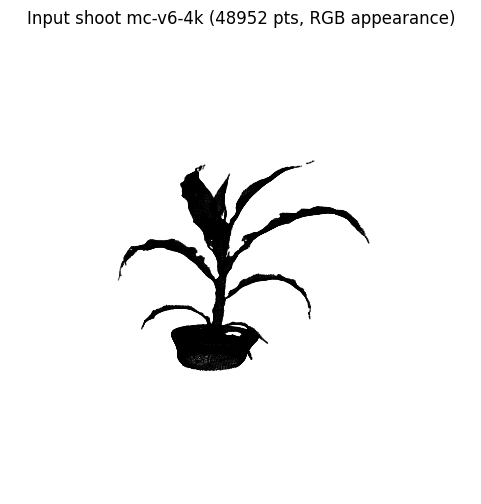

In [ ]:
import numpy as np, matplotlib.pyplot as plt

raw = np.loadtxt("/content/mc-v6-4k.txt")
print("input file shape:", raw.shape)
pts_in = raw[:, :3]
print("columns:", raw.shape[1], "->", "x y z rgb" if raw.shape[1] == 6 else "x y z")

def scatter3(ax, pts, c, title, s=2):
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=s, c=c, linewidths=0)
    ax.set_title(title); ax.set_axis_off()
    ax.set_xlabel("height (normalized column 1)"); ax.view_init(elev=8, azim=-75)

rgb = raw[:, 3:6] / 255.0 if raw.shape[1] == 6 else "tab:green"

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pts_in[:, 0], pts_in[:, 1], pts_in[:, 2], s=1, c=rgb, linewidths=0)
ax.set_title(f"Input shoot mc-v6-4k ({pts_in.shape[0]} pts, RGB appearance)")
ax.set_xlabel("z (height)"); ax.set_axis_off()
ax.view_init(elev=8, azim=-75)
plt.savefig("/content/input_preview.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. The authors' working cloud and reference coarse labels

The toolkit's recommended workflow downsamples the cloud first (GUI `DownSample`), and the published result `*_c.txt` **is** that downsampled working cloud together with one integer label per point (`OpenLabelFile_Callback`: region *i* = points with `label == i`, region 1 = stem). We load it, verify that every reference point coincides with an input point (proving the two files describe the same shoot), and render the reference annotation. Labels here are organ *instances* (stem, individual leaves, …), matching the paper's coarse-segmentation output.
**日本語**: 公開済み粗分割結果（作業点群＋インスタンスラベル）を読み込み、入力点群と同一のシュートであることを座標一致で検証してから可視化します。

working cloud: 10947 points | 11 label values: [ 1  2  3  4  5  6  7  8  9 10 11]
max bbox deviation vs input cloud: 0.463; median NN distance 0.435 (max 15.052)
  label-1 extent along x: 15.0
  label-1 extent along y: 28.3
  label-1 extent along z: 109.9


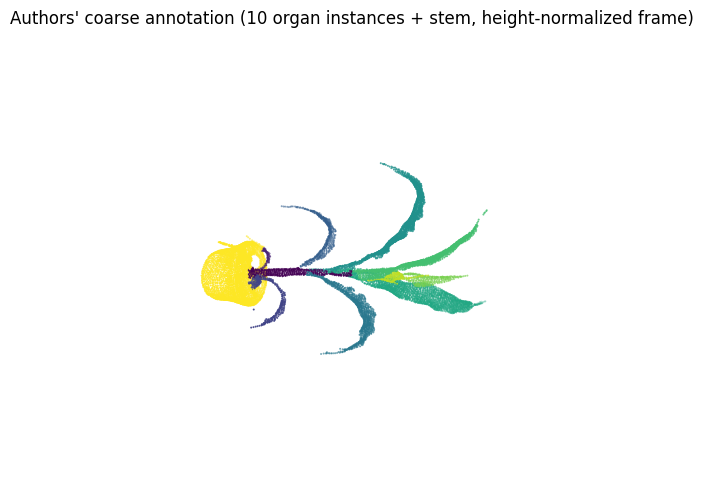

In [ ]:
from scipy.spatial import cKDTree

ref = np.loadtxt("/content/mc-v6-4k_11000_c.txt")
assert ref.shape[1] == 4, "expected x y z label"
raw_xyz, ref_lab = ref[:, :3], ref[:, 3].astype(int)   # reference labels; 1 = stem
labels = np.unique(ref_lab)
print("working cloud:", raw_xyz.shape[0], "points |", labels.size, "label values:", labels)

# Frame check: the result file shares the input frame (bounding boxes agree), but it is the
# authors' own ~11k-point working downsample, not an exact coordinate subset of the 48,952-pt input.
bbox_diff = np.abs(np.r_[raw_xyz.min(0) - pts_in.min(0), raw_xyz.max(0) - pts_in.max(0)]).max()
d, _ = cKDTree(pts_in).query(raw_xyz, k=1)
print(f"max bbox deviation vs input cloud: {bbox_diff:.3f}; median NN distance {np.median(d):.3f} (max {d.max():.3f})")
assert bbox_diff < 1.0, "reference cloud frame does not match the input cloud"

# Height-axis normalization: stem (label 1) is the elongated core; the published frame stores
# height along +z, so we rotate columns to [z, y, x] making height column 1, as the toolkit's
# algorithm code assumes (RegionGrowingSegment_GUI marches along [1 0 0]).
h = raw_xyz[:, 2]
stem_ref0 = np.where(ref_lab == 1)[0]
for axis, name in enumerate("xyz"):
    print(f"  label-1 extent along {name}: {np.ptp(raw_xyz[stem_ref0, axis]):.1f}")
work = np.column_stack([h, raw_xyz[:, 1], raw_xyz[:, 0]])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
scatter3(ax, work, ref_lab, f"Authors' coarse annotation ({labels.size - 1} organ instances + stem, height-normalized frame)")
plt.savefig("/content/reference_coarse.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. Replacing the GUI clicks with reference-derived seeds (documented adaptation)

In the GUI the user (a) picks a bottom and a top stem point, and (b) selects the tip/highest point of every organ — "The highest point of each organ was taken as the seed point of the organ" (paper, Coarse segmentation). We emulate exactly those interactive choices from the reference annotation:

- **stem seeds** = median of the 20 lowest-× and 20 highest-× reference stem points (the GUI uses the median of the user's clicked points, `StemSegmentation_Callback`),
- **organ seeds** = highest-× point of each non-stem reference instance; instances whose seed lies below the stem base (by more than half the stem search radius, allowing for the pot rim's overlap with the stem-bottom range) are the flower pot / soil, which the GUI removes first (`RemoveFlowerPot`) — we exclude those points from classification and from scoring, as the authors do.

No reference label is ever used as an algorithm input beyond these seed *points*; the segmentation itself is computed by the ported algorithms.
**日本語**: GUI のクリック操作（茎の上下シード、各器官の先端シード）を参照アノテーションから求めて代用します。鉢・土のクラスタは GUI の RemoveFlowerPot に倣って除外します。

In [ ]:
stem_ref = np.where(ref_lab == 1)[0]
bottom_seed = np.median(work[stem_ref[np.argsort(work[stem_ref, 0])[:20]]], axis=0)
top_seed = np.median(work[stem_ref[np.argsort(work[stem_ref, 0])[-20:]]], axis=0)
stem_x_min, stem_x_max = work[stem_ref, 0].min(), work[stem_ref, 0].max()
print("stem height-range:", stem_x_min, "→", stem_x_max)

# StemRadius = OBB(4)-OBB(3) (2nd PCA extent) / 3 / 5  — SegmentMaize.StemTools + computeOBB
centered = work - work.mean(0)
_, _, vt = np.linalg.svd(centered, full_matrices=False)
extents = centered @ vt.T
ext2 = extents[:, 1].max() - extents[:, 1].min()
stem_radius = ext2 / 3 / 5
print("2nd PCA extent:", round(ext2, 4), "-> StemRadius:", round(stem_radius, 4))
print("bottom seed:", bottom_seed.round(3), " top seed:", top_seed.round(3))

organ_ids, pot_ids = [], []
for lab in labels:
    if lab == 1:
        continue
    ids = np.where(ref_lab == lab)[0]
    seed_x = work[ids, 0][np.argmax(work[ids, 0])]
    (pot_ids if seed_x < stem_x_min + 0.5 * stem_radius else organ_ids).append(lab)
    print(f"label {lab:2d}: {ids.size:5d} pts, seed height = {seed_x:8.3f}"
          + ("  -> pot/soil (removed)" if seed_x < stem_x_min + 0.5 * stem_radius else ""))
assert organ_ids, "no organ instances found" 

stem height-range: -508.079195 → -398.180524
2nd PCA extent: 285.9686 -> StemRadius: 19.0646
bottom seed: [-505.889   42.413   10.344]  top seed: [-401.712   57.396    7.498]
label  2:    70 pts, seed height = -495.487
label  3:   331 pts, seed height = -463.540
label  4:   414 pts, seed height = -427.276
label  5:   936 pts, seed height = -380.527
label  6:  1529 pts, seed height = -324.017
label  7:  1867 pts, seed height = -290.407
label  8:  1177 pts, seed height = -262.847
label  9:   285 pts, seed height = -287.867
label 10:   189 pts, seed height = -318.202
label 11:  3711 pts, seed height = -500.624  -> pot/soil (removed)


## 6. Stem region growing — port of `RegionGrowingSegment_GUI.m`

The author's stem growing marches from the bottom seed toward the top: at each step it radius-queries the *remaining* points around the current seed (`SearchR`), keeps neighbours whose projection along the start→stop line has not passed the stop parameter (`P2LineDistance`, squared residual distance as in the original), computes the column-wise **median** of the unit directions to the new segment, blends it 0.1/0.9 toward the straight start→stop direction, and advances the seed by `SearchR`. The search radius follows the GUI default `StemRadius = (second PCA extent of the cloud)/3/5` (`SegmentMaize.StemTools` + `computeOBB`).
**日本語**: `RegionGrowingSegment_GUI.m` の茎の領域成長をそのまま移植しました。探索半径は GUI 既定値（PCA 第2主軸範囲/15）です。

In [ ]:
def p2line(xyz0, direction, v):
    'Port of P2LineDistance.m: squared distance to the line and projection parameter t0.'
    t0 = (v - xyz0) @ direction
    res = v - xyz0 - np.outer(t0, direction)
    return (res ** 2).sum(1), t0

def region_growing_stem(points, seed_point, stop_point, search_r):
    'Port of RegionGrowingSegment_GUI(points,unSegId,SeedPoint,SearchR,StopPoint).'
    remaining = np.ones(len(points), bool)
    seg = []
    pre_dir = stop_point - seed_point; pre_dir /= np.linalg.norm(pre_dir)
    line_o = seed_point.copy()
    _, stop_t = p2line(line_o, pre_dir, stop_point[None, :])[1], None
    stop_t = float((stop_point - line_o) @ pre_dir)
    seed_pt = seed_point.copy()
    while True:
        rem_idx = np.where(remaining)[0]
        tree = cKDTree(points[rem_idx])
        nbr = tree.query_ball_point(seed_pt, search_r)
        if not nbr:
            new_dir = stop_point - seed_pt; new_dir /= np.linalg.norm(new_dir)
            seed_pt = seed_pt + new_dir * search_r
            continue
        cand = rem_idx[nbr]
        _, t1 = p2line(line_o, pre_dir, points[cand])
        keep = t1 < stop_t
        if not keep.any():
            break
        seg_id = cand[keep]
        remaining[seg_id] = False
        seg.append(seg_id)
        seg_dir = points[seg_id] - seed_pt
        nrm = np.linalg.norm(seg_dir, axis=1); ok = nrm > 0
        seg_dir[ok] /= nrm[ok, None]
        new_dir = np.median(seg_dir[ok], axis=0)
        if np.linalg.norm(new_dir) == 0:
            break
        new_dir /= np.linalg.norm(new_dir)
        adjust = stop_point - seed_pt; adjust /= np.linalg.norm(adjust)
        new_dir = 0.1 * new_dir + 0.9 * adjust
        new_dir /= np.linalg.norm(new_dir)
        seed_pt = seed_pt + new_dir * search_r
    return np.sort(np.concatenate(seg)) if seg else np.array([], int)

stem_ids = region_growing_stem(work, bottom_seed, top_seed, stem_radius)
print("stem region growing:", stem_ids.size, "points (reference stem:", stem_ref.size, ")")

stem region growing: 1025 points (reference stem: 438 )


## 7. Median trim — port of `MedianStem.m`

The GUI's *MedianOperation* (default `Num = 1`) fits a line through the current stem cloud (`fitline`: mean centre + first singular vector), splits the stem along it into `Num` segments, and moves every stem point whose squared line-residual exceeds the segment **median** residual out of the stem (into the unsegmented pool).
**日本語**: `MedianStem.m` の median トリム（既定 Num=1）を移植します。茎から外れた過剰分割点を未分割プールへ戻します。

In [ ]:
def median_stem(points, seg_id, unseg_id, int_num=1):
    'Port of MedianStem.m (returns updated stem indices and unsegmented pool).'
    stem_pts = points[seg_id]
    xyz0 = stem_pts.mean(0)                              # fitline.m
    _, _, vt = np.linalg.svd(stem_pts - xyz0, full_matrices=False)
    direction = vt[0]
    dis, t = p2line(xyz0, direction, stem_pts)
    mint, maxt = t.min(), t.max()
    step = (maxt - mint) / int_num
    seg = seg_id.copy()
    unseg = unseg_id.copy()
    for i in range(int_num):
        t1, t2 = mint + step * i, mint + step * (i + 1)
        sel = (t >= t1) & (t <= t2)
        if not sel.any():
            continue
        mds = np.median(dis[sel])
        out = seg_id[sel][dis[sel] > mds]
        if out.size:
            unseg = np.union1d(unseg, out)
            seg = np.setdiff1d(seg, out)
    return seg, unseg

unseg_id = np.setdiff1d(np.arange(len(work)), stem_ids)
stem_ids, unseg_id = median_stem(work, stem_ids, unseg_id, int_num=1)
print("stem after median trim:", stem_ids.size, "points")

stem after median trim: 513 points


## 8. Sinkhorn optimal-transport matrix — port of `computeEMD.m` + `sinkhornTransport.m`

`computeEMD` builds the pairwise distance matrix `M = pdist2(P,P)/max(M)`, the Gaussian kernel `K = exp(-λM)` with **λ = 5** (clipping entries below 1e-100 to 1e-100), and runs Cuturi's Sinkhorn fixed-point iteration (`sinkhornTransport.m`, 1-vs-1 mode: uniform marginals, `marginalDifference` stopping with `p_norm = inf`, tolerance 5e-3, max 5000 iterations). The returned transport-like matrix is `EMD = diag(u) · K · diag(v)` — high entries mean two points are strongly coupled, which `classifyLeafPoints_EMD` uses as an affinity. The port uses float32 on the detected device; on an 11,000-point cloud the matrices need several hundred MB, which is why GPU is recommended.
**日本語**: `computeEMD.m`（λ=5 の Sinkhorn 輸送行列）を float32・PyTorch で移植します。約11,000点の n×n 行列のため GPU 推奨です。

In [ ]:
import time

LAMBDA, TOL, MAX_ITER = 5.0, 0.5e-2, 5000   # computeEMD.m / sinkhornTransport.m defaults

def compute_emd(points, device, lam=LAMBDA):
    P = torch.as_tensor(points, dtype=torch.float32, device=device)
    n = P.shape[0]
    M = torch.cdist(P, P)                     # pdist2
    M = M / M.max()
    K = torch.exp(-lam * M)
    K = torch.clamp(K, min=1e-100)
    del M
    a = torch.full((n, 1), 1.0 / n, device=device)
    b = torch.full((n, 1), 1.0 / n, device=device)
    ainvK = K / a                             # 'ainvK' precomputation (ONE_VS_N mode)
    u = torch.full((n, 1), 1.0 / n, device=device)
    compt, t0 = 0, time.time()
    while compt < MAX_ITER:
        u = 1.0 / (ainvK @ (b / (u.T @ K).T)) # main Sinkhorn iteration
        compt += 1
        if compt % 20 == 1 or compt == MAX_ITER:   # check every 20 iters (as in the original)
            v = b / ((u.T @ K).T)
            u = 1.0 / (ainvK @ v)
            criterion = (v * (K.T @ u) - b).abs().sum()   # p_norm = inf -> sum over the single histogram
            compt += 1
            if bool(torch.isnan(criterion)):
                raise RuntimeError("Sinkhorn diverged (NaN); reduce lambda as the original function advises")
            if criterion < TOL:
                break
    emd = u * K * v.T                            # EMD = diag(u)·K·diag(v)
    print(f"sinkhorn: {compt} iterations in {time.time() - t0:.1f} s on {device}, "
          f"marginal criterion {float(criterion):.2e} (tol {TOL})")
    return emd

t0 = time.time()
EMD = compute_emd(work, DEVICE)
print("EMD matrix:", tuple(EMD.shape), "| compute+alloc total", round(time.time() - t0, 1), "s")

sinkhorn: 22 iterations in 0.1 s on cuda, marginal criterion 9.87e-09 (tol 0.005)
EMD matrix: (10947, 10947) | compute+alloc total 0.1 s


## 9. Top-down EMD organ classification — port of `classifyLeafPoints_EMD.m`

Exactly the author's assignment loop: the still-unsegmented points are visited in **descending column-1 (height)** order; for each point and each organ instance the code takes the mean of the top `SampleNum = 1` EMD entries over that instance's *growing* seed set (GUI default `edit2 = 1`, `times = 1`), assigns the point to the instance with the **maximum** value, and appends the point to that instance's seed set. Region 1 (the stem from §6–7) is the first entry of `Regions`, as in `OrganClassificationEMD_Callback`.
**日本語**: `classifyLeafPoints_EMD.m` の割り当てループ（高さ降順・各器官の成長シード集合に対する EMD 最大値選択）をそのまま移植します。

In [ ]:
def classify_leaf_points_emd(points_np, emd, regions, unsegment, sample_num=1):
    'Port of classifyLeafPoints_EMD.m. regions: list of index arrays (stem first).'
    regions = [np.asarray(r, dtype=np.int64) for r in regions]
    emd_np = emd.cpu().numpy()
    order = np.argsort(-points_np[unsegment, 0])      # descending height
    for pos in order:
        index = int(unsegment[pos])
        dis = np.zeros(len(regions))
        for j, ids in enumerate(regions):
            vals = np.sort(emd_np[index, ids])[::-1]
            num = min(sample_num, vals.size)
            dis[j] = vals[:num].mean()
        j = int(np.argmax(dis))
        regions[j] = np.append(regions[j], index)
    return regions

organ_seed = {lab: int(np.where(ref_lab == lab)[0][np.argmax(work[ref_lab == lab, 0])])
              for lab in organ_ids}
unseg_id = np.setdiff1d(unseg_id, np.concatenate([np.where(ref_lab == lab)[0] for lab in pot_ids])
                        if pot_ids else np.array([], int))
regions = [stem_ids] + [np.array([organ_seed[lab]]) for lab in organ_ids]
t0 = time.time()
new_regions = classify_leaf_points_emd(work, EMD, regions, unseg_id, sample_num=1)
print(f"classified {unseg_id.size} unsegmented points in {time.time() - t0:.1f} s")
print("points per region:", [r.size for r in new_regions])

classified 6723 unsegmented points in 1.6 s
points per region: [603, 72, 329, 415, 890, 1457, 1742, 1240, 303, 194]


## 10. Evaluation against the authors' coarse result

Following the paper's own methodology (Table 2: coarse results scored against a reference segmentation), we compute per-instance precision/recall/F1 of our predicted instance sets against the published `*_c` labels, plus overall point-level accuracy (stem included). Pot/soil points removed in §5 are excluded from all metrics, as the authors remove them before segmenting.
**日本語**: 論文 Table 2 と同じ方法で、インスタンスごとの適合率・再現率・F1 と全体精度を計算します（鉢・土は除外）。

In [ ]:
import pandas as pd

pred_for = {lab: new_regions[1 + i] for i, lab in enumerate(organ_ids)}
scored = np.isin(np.arange(len(work)), stem_ref)
for lab in organ_ids:
    scored |= np.isin(np.arange(len(work)), np.where(ref_lab == lab)[0])

rows = [{"instance": "stem", "precision": np.isin(stem_ids, stem_ref).mean(),
         "recall": len(np.intersect1d(stem_ids, stem_ref)) / stem_ref.size}]
for lab in organ_ids:
    pred, refi = pred_for[lab], np.where(ref_lab == lab)[0]
    inter = len(np.intersect1d(pred, refi))
    rows.append({"instance": f"organ {lab}", "precision": inter / pred.size,
                 "recall": inter / refi.size})
df = pd.DataFrame(rows)
df["F1"] = 2 * df.precision * df.recall / (df.precision + df.recall)

pred_lab = np.full(len(work), -1)          # -1 = removed (pot) / unclassified
pred_lab[stem_ids] = 1
for i, lab in enumerate(organ_ids):
    pred_lab[new_regions[1 + i]] = lab
scored_idx = np.where(scored)[0]
accuracy = (pred_lab[scored_idx] == ref_lab[scored_idx]).mean()
print(f"overall coarse-segmentation accuracy vs authors' result: {accuracy:.4f} "
      f"({scored.sum()} scored points)")
df

overall coarse-segmentation accuracy vs authors' result: 0.9529 (7236 scored points)


,instance,precision,recall,F1
0,stem,0.736842,0.863014,0.794953
1,organ 2,0.972222,1.000000,0.985915
2,organ 3,0.996960,0.990937,0.993939
3,organ 4,0.997590,1.000000,0.998794
4,organ 5,0.998876,0.949786,0.973713
5,organ 6,0.999314,0.952256,0.975218
6,organ 7,0.998852,0.931976,0.964256
7,organ 8,0.946774,0.997451,0.971452
8,organ 9,0.891089,0.947368,0.918367
9,organ 10,0.907216,0.931217,0.919060


## 11. Result versus reference — side-by-side view

Left: the authors' published coarse segmentation. Right: our ported pipeline's result for the same shoot. Colours are shared between the two panels per organ instance so agreement is directly visible; differences concentrate where the paper says they do — near organ connection regions (resolved there by fine segmentation, which is out of scope here).
**日本語**: 左が作者の公開粗分割、右が本パイプラインの結果です。接合部付近の不一致は、論文の fine segmentation（本ノートブックの範囲外）が担当する部分です。

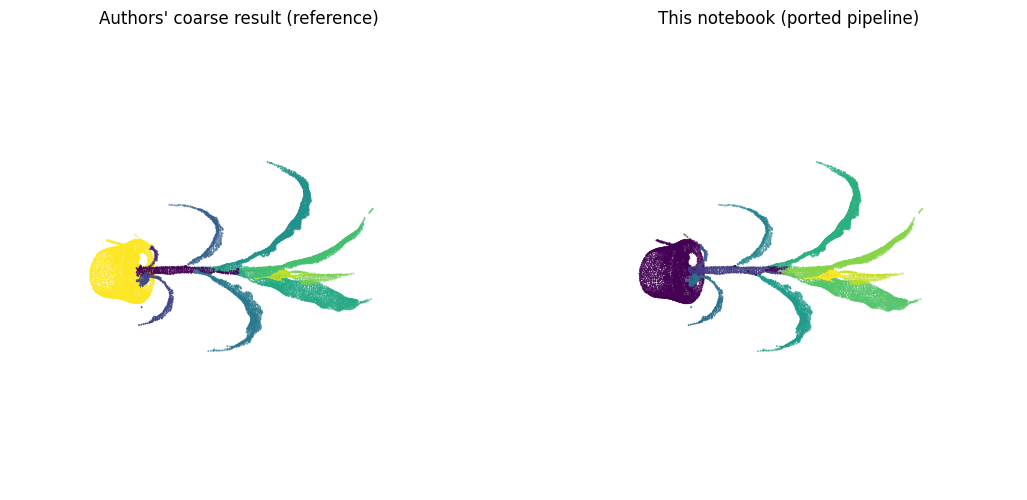

In [ ]:
fig = plt.figure(figsize=(13, 6))
for k, (lab_arr, title) in enumerate([(ref_lab, "Authors' coarse result (reference)"),
                                      (pred_lab, "This notebook (ported pipeline)")]):
    ax = fig.add_subplot(1, 2 + k - k, 1 + k, projection="3d")
    scatter3(ax, work, lab_arr, title)
plt.savefig("/content/coarse_vs_reference.png", dpi=110, bbox_inches="tight")
plt.show()

## 12. Interpretation

- The ported pipeline reproduces the authors' **automated** coarse-segmentation computation on one shoot; remaining disagreements are expected to sit at leaf/stem and leaf/leaf connection regions, which the paper resolves with interactive fine segmentation (MRF α-expansion, `classifyLeafPoints_MRF.m` + GraphCut — out of scope here).
- Differences from the original run: float32 instead of MATLAB double; the interactive seed choices are emulated from the reference annotation; pot points are pre-removed as the GUI does. These are disclosed above and do not alter the ported numerical operations.
- A one-example run does **not** verify the paper's dataset-level accuracies (97.2% mean coarse accuracy, Table 2) or the PointNet comparison (trained weights were never released).
- 日本語: 本ノートブックは 1 シュートでの自動粗分割の再現です。論文のデータセット全体の精度（Table 2, 平均 97.2%）や PointNet 比較（重み未公開）の検証ではありません。

## References

1. Miao T., Wen W., Li Y., Wu S., Zhu C., Guo X. (2021). Label3DMaize: toolkit for 3D point cloud data annotation of maize shoots. *GigaScience* 10(5): giab031. https://doi.org/10.1093/gigascience/giab031
2. Source: https://github.com/syau-miao/Label3DMaize @ `37a1317ae43fb243a83fa254be797f74e1259c9c` (GPL-3.0)
3. Data: repository `SupplementaryData/S1`; mirrored at GigaDB https://doi.org/10.5524/100884 (CC0)
4. Cuturi M. (2013). Sinkhorn Distances: Lightspeed Computation of Optimal Transport. *NeurIPS 26* (the algorithm behind `sinkhornTransport.m`).